# DQO: entender los datos, el entrenamiento y los errores

Este cuaderno contiene **resultados ejecutados**, tablas y figuras. No necesita leer JSON ni un dashboard. Ejecute las celdas en orden para repetir el análisis; la celda de entrenamiento vuelve a ajustar los tres modelos. Las salidas guardadas se calcularon ejecutando estas mismas celdas con Python del entorno `.venv` (sin servidor Jupyter).

**Pregunta:** ¿cómo cambia el error al estimar DQO en una visita según estación, año y temporada? Se conocen otras mediciones de la visita actual y los resultados de visitas anteriores. Esto no es predecir varios meses hacia adelante sin nuevas observaciones.

MAE y RMSE se expresan en **mg O2/L** y mejoran al bajar. R² es adimensional, mejora al acercarse a 1 y puede ser negativo. El R² global no describe necesariamente cada estación.

In [17]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Diagnosis_Algorithms import ejecutar_evaluacion, mostrar_resultados
from Data_Manage import Data_Manage
from Performance_Diagnostics import resumen_metricas
pd.set_option('display.max_colwidth', 65)
CSV = Path('Data_historica_de_calidad_de_agua_20260223.csv')
assert CSV.exists(), 'Abra el notebook desde la raíz del proyecto.'


## 1. Leer el CSV: una fila no es una muestra de aprendizaje

El archivo está en formato largo: una misma visita tiene filas para pH, conductividad, DQO, etc. Contar todas como ejemplos independientes sobreestima el tamaño del conjunto. La unidad de evaluación es una **estación y fecha/hora**. Se agregan con mediana mediciones repetidas de la misma propiedad/unidad y visita; esto también puede combinar códigos de muestra diferentes, una limitación registrada.

La normalización convierte encabezados y propiedades a mayúsculas sin tildes. Las fechas IDEAM se interpretan con meses ingleses explícitos. No se eliminan extremos de DQO. Las unidades distintas de una propiedad quedan en columnas diferentes; la DQO debe estar en mg O2/L.

In [18]:
raw = pd.read_csv(CSV)
display(raw.head(8))
dqo_raw = raw[raw['PROPIEDAD OBSERVADA'].str.contains('DEMANDA QUIMICA', na=False)]
display(pd.DataFrame({'cantidad': [len(raw), raw['NOMBRE DEL PUNTO DE MONITOREO'].nunique(), len(dqo_raw), dqo_raw.RESULTADO.astype(str).str.match(r'^\s*[<>]').sum()]}, index=['filas largas', 'estaciones', 'registros DQO', 'DQO censuradas']))

,NOMBRE DEL PUNTO DE MONITOREO,LATITUD,LONGITUD,ELEVACIÓN (m.s.n.m.),CORRIENTE,ZONA HIDROGRÁFICA - ZH,SZH - Código (#Área#Zona##Subzona),Nombre Subzona Hidrográfica,DEPARTAMENTO,MUNICIPIO,FECHA,PROPIEDAD OBSERVADA,RESULTADO,UNIDAD DEL RESULTADO,PROYECTO,CODIGO__MUESTRA
0,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2007 Mar 09 12:00:00 AM,ALUMINIO POTENCIALMENTE BIODISPONIBLE,5339,mg Al/kg,Ideam,"14,615"
1,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2013 Nov 09 12:00:00 AM,ALUMINIO POTENCIALMENTE BIODISPONIBLE,12560,mg Al/Kg,Ideam,"22,820"
2,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2016 Nov 07 12:00:00 AM,ALUMINIO POTENCIALMENTE BIODISPONIBLE,4408,mg Al/Kg,Ideam,"25,379"
3,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2013 Nov 09 12:00:00 AM,ALUMINIO TOTAL EN AGUA,12,mg Al/L,Ideam,"22,820"
4,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2016 Nov 07 12:00:00 AM,ALUMINIO TOTAL EN AGUA,7.31,mg Al/L,Ideam,"25,379"
5,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2007 Mar 09 12:00:00 AM,CADMIO POTENCIALMENTE BIODISPONIBLE,1.5,mg Cd/kg,Ideam,"14,615"
6,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2011 Apr 11 12:00:00 AM,CADMIO POTENCIALMENTE BIODISPONIBLE,1.29,mg Cd/Kg,Ideam,"20,148"
7,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,5.7375,-75.5975,612,ARMA,Cauca,"2,618",Río Arma,CALDAS,AGUADAS,2013 Nov 09 12:00:00 AM,CADMIO POTENCIALMENTE BIODISPONIBLE,<0.5,mg Cd/Kg,Ideam,"22,820"


,cantidad
filas largas,134261
estaciones,243
registros DQO,6694
DQO censuradas,1566


## 2. Preparación y entrenamiento común

1. Quitar duplicados exactos; detectar fechas/números inválidos. `<3,00` representa un límite: en covariables se aproxima por 1,5 y se conserva un indicador. Un límite superior `>x` no se convierte en etiqueta exacta.
2. Para DQO, `exclude` deja sin etiqueta las visitas censuradas; `half_limit` permite un análisis de sensibilidad. Excluirlas altera la población evaluada: estos resultados corresponden a DQO cuantificada.
3. Pivotar a visitas y conservar coordenadas/elevación por fecha, sin rellenarlas con información futura.
4. Añadir calendario, tiempo desde la visita anterior, cantidad de visitas previas y DQO histórica. `dqo_lag_1` usa la última DQO disponible antes de la visita; si faltan resultados, los lags pueden repetir una DQO antigua. Se añade su antigüedad.
5. Separar globalmente por fechas únicas: primeros 60 % para entrenamiento, siguientes 20 % validación y resto prueba. Son proporciones de fechas, no de filas. Los cortes se pueden fijar explícitamente.
6. Seleccionar variables químicas con cobertura >=70 % en entrenamiento. Ajustar medianas, escalado y transformación del objetivo solo en entrenamiento. No usar la DQO actual ni su censura como predictores.
7. Construir ventanas de cinco visitas de la misma estación, incluida la actual. Los tres modelos evalúan los mismos extremos de ventana con DQO conocida. XGBoost/SVM reciben la última fila y sus lags; LSTM recibe toda la secuencia. Tienen distinta representación, pero las mismas etiquetas y fechas de evaluación.
8. XGBoost: hasta 800 árboles, parada temprana en validación. SVM: 12 combinaciones de C/epsilon/gamma elegidas por RMSE de validación. LSTM: 64 unidades y capa densa; hasta 60 épocas, parada temprana y orden cronológico sin mezclar filas. No se reajustan con prueba.

Los resultados previos de prueba pueden entrar en las ventanas de visitas posteriores: evaluación de visitas sucesivas con resultados ya disponibles, no pronóstico fijo sin actualización de observaciones.

In [19]:
resultados = ejecutar_evaluacion(CSV, output_dir='outputs/analisis_actual', export_csv=False, verbose=False)
preparados = resultados['prepared']
display(resultados['diagnostics']['partitions'])
print('Cortes:', preparados.split_config['train_end'], preparados.split_config['validation_end'])
print('SHA256 de los datos:', resultados['source_sha256'])
print('Predictores seleccionados:', len(preparados.feature_cols))
display(preparados.frame[['sample_id','station','date','y_true','gap_days','history_count','split','eligible','exclusion_reason']].head(12))

,split,N,stations,start,end,target_mean,target_median,target_max
0,train,2679,176,2005-11-22,2015-08-11,45.840426,26.0,620.0
1,validation,877,179,2015-08-12,2020-02-06,47.532497,26.0,855.0
2,test,974,200,2020-02-07,2024-11-23,46.174538,27.0,789.0


Cortes: 2015-08-11T00:00:00 2020-02-06T00:00:00
SHA256 de los datos: 2ef05b6ffa7be8b33c0f4bea51e467a539f5de61365f3589f8cf892414243554
Predictores seleccionados: 60


,sample_id,station,date,y_true,gap_days,history_count,split,eligible,exclusion_reason
0,c7946e1d69132f9b65d9,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,2007-03-09,63.0,NaN,0,train,False,insufficient_history
1,a73c5b2b0dd9f2cdb3c5,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,2011-04-11,11.0,1494.0,1,train,False,insufficient_history
2,d5718608eb03798e2705,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,2013-11-09,NaN,943.0,2,train,False,censored_target
3,073cd07203225a1dda73,ARMA_CAL_AGUADAS_DESEMBOCADURA RIO ARMA,2016-11-07,19.0,1094.0,3,validation,False,insufficient_history
4,9b39d35b612dbb03a9bd,BACHE_HUI_NEIVA_PTE.SAN FRANCISCO METALICO - BACHE,2006-04-27,47.0,NaN,0,train,False,insufficient_history
5,5895dd43305a7772f33a,BACHE_HUI_NEIVA_PTE.SAN FRANCISCO METALICO - BACHE,2006-06-14,NaN,48.0,1,train,False,censored_target
6,c4f50f29f62cc9c39e02,BACHE_HUI_NEIVA_PTE.SAN FRANCISCO METALICO - BACHE,2007-04-26,70.0,316.0,2,train,False,insufficient_history
7,e804acf2afc92ad23272,BACHE_HUI_NEIVA_PTE.SAN FRANCISCO METALICO - BACHE,2007-07-25,14.0,90.0,3,train,False,insufficient_history
8,dd069478f4d1dd33a879,BACHE_HUI_NEIVA_PTE.SAN FRANCISCO METALICO - BACHE,2008-05-29,24.0,309.0,4,train,True,
9,aa0be17fab70634eb923,BACHE_HUI_NEIVA_PTE.SAN FRANCISCO METALICO - BACHE,2008-09-24,65.0,118.0,5,train,True,


## 3. Resultado principal: MAE, RMSE y R²

Esta es la tabla principal, también impresa por `mostrar_resultados()` en `Diagnosis_Algorithms.py`. Se evalúa después de invertir escalado y logaritmo. Las predicciones negativas se proyectan a cero; los valores reales no se recortan. La comparación se acompaña de referencias: media y mediana de entrenamiento, y última DQO observada por estación.

Entrenamiento muestra desempeño aparente y no demuestra generalización. Validación participó en elegir modelos. Solo la tabla de prueba representa el período reservado.

In [20]:
principales = resultados['metrics']['global'].query("split == 'test'")[['model','N','MAE','RMSE','R2']]
display(principales.round(4))
display(resultados['diagnostics']['baselines'].query("split == 'test'").round(4))
display(pd.concat([resultados['train_metrics'], resultados['metrics']['global'][['model','split','N','MAE','RMSE','R2']]], ignore_index=True).round(4))

,model,N,MAE,RMSE,R2
0,LSTM,974,19.7672,45.0055,0.4977
2,SVM,974,22.6490,51.7085,0.3369
4,XGBoost,974,18.4990,45.7542,0.4808


,model,split,N,MAE,RMSE,R2
3,Media entrenamiento,test,974,33.9304,63.4997,-0.0000
4,Mediana entrenamiento,test,974,28.7248,66.6266,-0.1009
5,Ultima DQO observada,test,974,32.0082,71.0993,-0.2537


,model,split,N,MAE,RMSE,R2
0,XGBoost,train,2679,12.1871,27.1641,0.7667
1,LSTM,train,2679,13.5988,29.6153,0.7227
2,SVM,train,2679,14.5059,32.2338,0.6715
3,LSTM,test,974,19.7672,45.0055,0.4977
4,LSTM,validation,877,19.3778,42.7613,0.5658
5,SVM,test,974,22.6490,51.7085,0.3369
6,SVM,validation,877,21.4770,49.9583,0.4074
7,XGBoost,test,974,18.4990,45.7542,0.4808
8,XGBoost,validation,877,19.1443,44.9661,0.5199


## 4. Distribución espacial y temporal

Cada agrupación recalcula las métricas a partir de sus observaciones; no promedia R² de otras tablas. `N` es imprescindible: R² no se define con una sola observación o DQO constante. `insufficient_samples` marca grupos de menos de cinco observaciones, sin eliminarlos de la tabla completa.

La temporada por defecto es un **proxy de calendario bimodal no validado localmente**: dic-feb seca_1, mar-may lluviosa_1, jun-ago seca_2, sep-nov lluviosa_2. Colombia tiene regímenes regionales distintos. El calendario se puede pasar como un diccionario Python `season_config={'source':'fuente local', 'stations': {'NOMBRE': {'1':'seca', ...}}}` con los doce meses. No confundir estas etiquetas con precipitación observada. El año es calendario, no año hidrológico.

Las 8 tablas están en `resultados['metrics']`: global, station, year, season, year_season, station_year, station_season, station_year_season.

In [21]:
display(resultados['metrics']['year'].query("split == 'test'")[['model','year','N','MAE','RMSE','R2']].round(3))
display(resultados['metrics']['season'].query("split == 'test'")[['model','season','N','MAE','RMSE','R2']].round(3))
estaciones = resultados['metrics']['station'].query("split == 'test'")
display(estaciones[['model','station','N','MAE','RMSE','R2','insufficient_samples']].sort_values('RMSE',ascending=False).head(20))
# Para una estación concreta, descomente:
# display(estaciones[estaciones.station.eq('NOMBRE EXACTO DE LA ESTACION')])


,model,year,N,MAE,RMSE,R2
0,LSTM,2020,134,19.054,39.499,0.648
1,LSTM,2021,193,27.060,70.254,0.404
2,LSTM,2022,267,22.278,45.204,0.526
3,LSTM,2023,211,14.656,25.398,0.392
4,LSTM,2024,169,14.418,27.683,0.478
11,SVM,2020,134,23.269,50.727,0.419
12,SVM,2021,193,30.065,76.136,0.300
13,SVM,2022,267,26.172,56.201,0.267
14,SVM,2023,211,15.676,26.980,0.314
15,SVM,2024,169,16.829,29.165,0.421


,model,season,N,MAE,RMSE,R2
0,LSTM,lluviosa_1,162,24.321,65.473,0.435
1,LSTM,lluviosa_2,488,18.718,35.399,0.520
2,LSTM,seca_1,70,25.663,62.907,0.654
3,LSTM,seca_2,254,17.254,39.178,0.334
8,SVM,lluviosa_1,162,28.477,73.128,0.295
9,SVM,lluviosa_2,488,20.736,40.016,0.387
10,SVM,seca_1,70,35.221,87.191,0.336
11,SVM,seca_2,254,19.142,40.873,0.276
16,XGBoost,lluviosa_1,162,23.730,67.625,0.397
17,XGBoost,lluviosa_2,488,17.171,34.161,0.553


,model,station,N,MAE,RMSE,R2,insufficient_samples
474,SVM,RCA_CHULO_BOY_TUTA_PILAS LAS [24037250],1,271.126788,271.126788,NaN,True
531,SVM,RCA_NEGRO_CUN_PUERTO SALGAR_PTO.LIBRE [23067040],12,101.360081,202.380105,0.037674,False
541,SVM,RCA_PASTO_NAR_PASTO_BOCATOMA CENTENARIO [52047030],6,90.710677,195.207948,0.023668,False
162,LSTM,RCA_PASTO_NAR_PASTO_BOCATOMA CENTENARIO [52047030],6,84.994818,193.595031,0.039736,False
437,SVM,RCA_BOGOTA_CUN_EL COLEGIO_PTE.CARRETERA LA MESA - MESITAS,6,153.889254,189.710054,-1.174277,False
95,LSTM,RCA_CHULO_BOY_TUTA_PILAS LAS [24037250],1,189.598354,189.598354,NaN,True
438,SVM,RCA_BOGOTA_CUN_GIRARDOT_CAMPINA LA [21209200],13,111.353167,186.827401,-0.272137,False
920,XGBoost,RCA_PASTO_NAR_PASTO_BOCATOMA CENTENARIO [52047030],6,80.842965,185.798292,0.115524,False
816,XGBoost,RCA_BOGOTA_CUN_EL COLEGIO_PTE.CARRETERA LA MESA - MESITAS,6,143.559274,182.351312,-1.008871,False
910,XGBoost,RCA_NEGRO_CUN_PUERTO SALGAR_PTO.LIBRE [23067040],12,83.489162,180.947513,0.230707,False


In [22]:
# Figuras existentes de esta ejecución, integradas en el cuaderno.
for nombre in ['year_RMSE.png','map_station_MAE.png','season_R2.png','station_year_MAE_01.png']:
    ruta = Path(resultados['output_dir'])/nombre
    if ruta.exists():
        fig, ax = plt.subplots(figsize=(14,6))
        ax.imshow(plt.imread(ruta)); ax.axis('off')
        display(fig); plt.close(fig)
print('Los mapas solo representan puntos observados; no extrapolan el error a zonas sin datos.')

<Figure size 1400x600 with 1 Axes>

<Figure size 1400x600 with 1 Axes>

<Figure size 1400x600 with 1 Axes>

<Figure size 1400x600 with 1 Axes>

Los mapas solo representan puntos observados; no extrapolan el error a zonas sin datos.


## 5. Por qué el desempeño es limitado: evidencia, no una causa supuesta

Se comprueban el tamaño efectivo, concentración del error en pocos casos, diferencias entre estaciones conocidas/nuevas y disponibilidad de las covariables. El umbral DQO >=100 de esta tabla es descriptivo, no regulatorio. Un sesgo negativo indica subestimación.

La mediana de DQO es mucho menor que la media: la distribución tiene una cola derecha. Una pérdida calculada sobre log1p(DQO) reduce el peso relativo de los picos. No implica que los datos sean incorrectos ni justifica borrar esos casos. Una secuencia de cinco visitas puede abarcar años y no cinco pasos igualmente separados; añadir gap_days ayuda, pero no convierte la LSTM en un modelo de tiempo continuo.

In [23]:
for observacion in resultados['diagnostics']['observations']:
    print('-', observacion)
display(resultados['diagnostics']['error_concentration'].round(4))
display(resultados['diagnostics']['station_generalization'].round(4))
display(resultados['diagnostics']['feature_missingness'].round(3))
display(preparados.frame[preparados.frame.eligible].groupby('split').y_true.describe(percentiles=[.5,.9,.95,.99]).round(2))
fig, ax = plt.subplots(figsize=(7,4))
for nombre, g in resultados['predictions'].query("split == 'test'").groupby('model'):
    ax.scatter(g.y_true,g.y_pred,s=8,alpha=.3,label=nombre)
lim = resultados['predictions'].y_true.max(); ax.plot([0,lim],[0,lim],'k--')
ax.set(xlabel='DQO observada (mg O2/L)',ylabel='DQO estimada (mg O2/L)'); ax.legend()
display(fig); plt.close(fig)

- 134261 filas largas no equivalen a muestras independientes: 6835 visitas, 5114 con DQO utilizable.
- Se excluyen por defecto etiquetas censuradas (1566 registros); esto limita el alcance a DQO cuantificada y puede sesgar hacia concentraciones mayores.
- Mediana entre visitas: 117 días; 2004 intervalos superan 180 días. No se inventan fechas ni se interpolan etiquetas.
- Una ventana de 5 visitas abarca una mediana de 519 días; no equivale a pasos temporales uniformes.
- Prueba cubre 200 estaciones: 111 tienen menos de 5 observaciones. R² local puede ser inestable aunque el global sea positivo.
- La DQO se conserva sin recortar extremos. El RMSE pondera fuertemente pocos errores grandes; consulte su concentración y sesgo para DQO >=100 (umbral descriptivo, no normativo).
- Transformación log1p: True. Optimizar pérdida en log no equivale a minimizar RMSE en mg O2/L; puede favorecer concentraciones bajas y subestimar picos.
- No se demuestra una causa con estos descriptivos. Cambios de c

,model,worst_5pct_N,squared_error_share_worst_5pct,high_DQO_threshold,high_DQO_N,high_DQO_bias,high_DQO_MAE
0,LSTM,49,0.8356,100,94,-89.3326,93.9014
1,SVM,49,0.8473,100,94,-108.6432,111.7001
2,XGBoost,49,0.8671,100,94,-89.6820,92.4984


,model,station_group,stations,N,MAE,RMSE,R2
0,LSTM,Con etiquetas en train,151,751,21.1324,49.5334,0.5039
1,LSTM,Sin etiquetas en train,49,223,15.1697,24.1642,0.2902
2,SVM,Con etiquetas en train,151,751,24.8841,57.5116,0.3312
3,SVM,Sin etiquetas en train,49,223,15.1220,23.2219,0.3445
4,XGBoost,Con etiquetas en train,151,751,19.7840,50.6498,0.4812
5,XGBoost,Sin etiquetas en train,49,223,14.1717,22.4509,0.3873


split,feature,test,train,validation
0,chem::CONDUCTIVIDAD ELECTRICA [ΜS/CM],0.020,0.007,0.009
1,chem::FOSFORO REACTIVO DISUELTO [MGP-PO4-3/L],0.093,0.259,0.254
2,chem::NITRATO [MGN-NO3-/L],0.073,0.266,0.251
3,chem::NITROGENO AMONIACAL [MGN-NH3-/L],0.279,0.256,0.229
4,chem::OXIGENO DISUELTO (OD) [MGO2/L],0.011,0.051,0.034
5,chem::PH [UNIDADESDEPH],0.018,0.008,0.003
6,chem::SOLIDOS SUSPENDIDOS TOTALES [MG/L],0.004,0.008,0.031
7,chem::TEMPERATURA [°C],0.011,0.009,0.024
8,chem::TURBIDEZ [NTU],0.054,0.007,0.081


,count,mean,std,min,50%,90%,95%,99%,max
split,,,,,,,,,
test,974.0,46.17,63.53,10.0,27.0,98.0,154.35,295.27,789.0
train,2679.0,45.84,56.25,10.0,26.0,102.0,160.00,290.00,620.0
validation,877.0,47.53,64.93,10.0,26.0,99.4,170.60,320.00,855.0


<Figure size 700x400 with 1 Axes>

## 6. Experimentos diagnósticos solo en validación

Se mantiene exactamente la cohorte y los cortes. Se cambia una decisión cada vez: entrenar XGBoost sin logaritmo o reducir la cobertura mínima de covariables a 15 %. Así se prueba si excluir variables escasas o minimizar error en log contribuye al problema. **No se selecciona por prueba, ni se sustituye silenciosamente el resultado principal.** Son exploraciones posteriores al primer experimento: cualquier mejora requiere confirmación en otro período no utilizado.

La función objetivo sigue siendo cuadrática, pero la parada temprana monitoriza RMSE en el espacio transformado del objetivo. La comparación reportada aquí siempre se vuelve a mg O2/L.

In [24]:
from XGBoost_Algorithm import XGBoost_Algorithm
experimentos = []
base = resultados['metrics']['global'].query("model == 'XGBoost' and split == 'validation'").iloc[0]
experimentos.append(dict(experimento='Original: log, cobertura 70%', variables=len(preparados.feature_cols), **{k:base[k] for k in ['N','MAE','RMSE','R2']}))
for etiqueta, log, cobertura in [('Sin log, cobertura 70%',False,.7), ('Log, cobertura 15%',True,.15)]:
    gestor = Data_Manage(CSV, sequence_length=5, transformar_target_log=log)
    datos = gestor.preparar_evaluacion(train_end=preparados.split_config['train_end'], validation_end=preparados.split_config['validation_end'], coverage_threshold=cobertura)
    assert datos.partitions['validation'].metadata.sample_id.equals(preparados.partitions['validation'].metadata.sample_id)
    modelo = XGBoost_Algorithm().fit(datos)
    valid = datos.partitions['validation']
    pred = np.maximum(datos.inverse_target(modelo.predict(valid)),0)
    experimentos.append(dict(experimento=etiqueta, variables=len(datos.feature_cols), **resumen_metricas(valid.metadata.y_true,pred)))
experimentos = pd.DataFrame(experimentos)
display(experimentos.round(4))
# No se predice test en estos experimentos exploratorios.


,experimento,variables,N,MAE,RMSE,R2
0,"Original: log, cobertura 70%",60,877,19.1443,44.9661,0.5199
1,"Sin log, cobertura 70%",60,877,18.9088,40.5156,0.6102
2,"Log, cobertura 15%",144,877,18.0285,42.0506,0.5801


## 7. Curvas de entrenamiento y explicación del error

La curva LSTM permite distinguir sobreajuste de falta de épocas. Menor pérdida de entrenamiento con validación que deja de mejorar es evidencia de sobreajuste en este experimento; entrenar más no garantiza mejora.

SHAP aquí explica un **Random Forest auxiliar del error absoluto**, distinto de los predictores de DQO. Aprende de residuos de validación con elevación, coordenadas, huecos entre visitas, historial y mes. Se mide su capacidad de predecir errores en prueba y se compara con la mediana del error en validación. Si no mejora la referencia, la importancia SHAP no demuestra factores explicativos confiables. Son asociaciones, no causas. Además, validación se usó para seleccionar los modelos de DQO y sus residuos pueden ser optimistas.

In [25]:
historia = resultados['training']['LSTM']['history']
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(range(1,len(historia['loss'])+1),historia['loss'],label='train')
ax.plot(range(1,len(historia['val_loss'])+1),historia['val_loss'],label='validation')
ax.set(xlabel='Epoca',ylabel='MSE de DQO transformada'); ax.legend(); display(fig); plt.close(fig)
analisis_error = resultados['error_analysis']
display(pd.DataFrame([dict(model=m,estado=v['status'],R2_auxiliar=v.get('surrogate_test_R2'),mejora_MAE=v.get('MAE_skill_against_validation_median')) for m,v in analisis_error['models'].items()]))
for nombre, tabla in analisis_error['tables'].items():
    if nombre.endswith('shap_error_global'):
        display(tabla.sort_values('mean_abs_shap',ascending=False).round(4))


<Figure size 700x400 with 1 Axes>

,model,estado,R2_auxiliar,mejora_MAE
0,LSTM,low_predictive_skill,0.074366,-0.177962
1,SVM,low_predictive_skill,0.143362,-0.090283
2,XGBoost,low_predictive_skill,0.103559,-0.239724


,model,feature,N,mean_abs_shap,mean_signed_shap
3,LSTM,latitude,300,3.2735,0.0898
2,LSTM,history_count,300,3.0331,1.1036
0,LSTM,elevation,300,1.7942,0.3047
6,LSTM,month_sin,300,1.7355,0.0118
1,LSTM,gap_days,300,1.7203,0.3299
4,LSTM,longitude,300,1.4433,0.3411
5,LSTM,month_cos,300,0.9928,0.0347


,model,feature,N,mean_abs_shap,mean_signed_shap
3,SVM,latitude,300,4.9331,0.4045
2,SVM,history_count,300,4.2020,1.2844
0,SVM,elevation,300,2.0190,0.0146
1,SVM,gap_days,300,1.7371,0.6187
4,SVM,longitude,300,1.6528,0.7817
6,SVM,month_sin,300,1.5429,0.1699
5,SVM,month_cos,300,1.0891,-0.0497


,model,feature,N,mean_abs_shap,mean_signed_shap
2,XGBoost,history_count,300,4.3545,1.4305
3,XGBoost,latitude,300,3.8910,-0.0734
0,XGBoost,elevation,300,1.6656,0.2219
6,XGBoost,month_sin,300,1.6039,0.0549
4,XGBoost,longitude,300,1.5434,0.4458
1,XGBoost,gap_days,300,1.4706,0.5250
5,XGBoost,month_cos,300,1.1737,0.0351


## 8. Qué significa CRISP-ML(Q) en este proyecto

- **Comprensión:** estimar DQO en visitas con covariables disponibles y comparar errores espaciales/temporales.
- **Datos y calidad:** validar unidades, censura, duplicados, fechas, cobertura y tamaño de los grupos; mantener identidad de cada visita.
- **Preparación:** cortes cronológicos, imputación/selección/escalado ajustados solo con pasado, ventanas por estación.
- **Modelado:** seleccionar mediante validación y conservar prueba para evaluación final.
- **Evaluación:** métricas físicas, referencias simples, grupos con N, figuras y diagnóstico de residuos. Ninguna métrica por sí sola certifica utilidad operacional.
- **Seguimiento propuesto:** repetir con cortes anuales sucesivos y vigilar cambios en cobertura/error. Este código no despliega un servicio ni implementa monitoreo continuo.

**Siguientes experimentos razonables:** validar calendarios locales; estudiar etiquetas censuradas con métodos específicos; ampliar covariables cuando tengan calidad; comparar ventanas cortas y largas en validación; evaluación temporal de origen móvil. Para medir transferencia a estaciones nunca vistas hace falta reservar estaciones completas. Las tablas espaciales actuales no equivalen a ese experimento.

El CSV original se conserva. Los CSV de la ejecución previa son históricos y no se cargan en este cuaderno. `export_csv=False` devuelve las tablas en memoria; no genera JSON ni CSV nuevos. Las figuras se guardan como PNG y se muestran arriba.

## 9. Resultado final de censura y regularización

Esta sección lee las tablas compactas del único historial del proyecto; no usa JSON ni CSV derivados. La política `train_half_limit` reemplaza `<L` por `L/2` exclusivamente durante entrenamiento. La cohorte de validación y prueba sigue formada por etiquetas exactas, por lo que la comparación conserva las mismas 877 y 974 observaciones.


In [10]:
from Experiment_Proposals import leer_tabla_informe

conteos = leer_tabla_informe('counts')
validacion_censura = leer_tabla_informe('validation')
prueba_censura = leer_tabla_informe('test')
regiones = leer_tabla_informe('Regiones: within_regions')

seleccionados = [
    'XGBoost__exclude', 'XGBoost__train_half_limit',
    'SVM__exclude', 'SVM__train_half_limit',
    'LSTM_32_d03__exclude', 'LSTM_32_d03__train_half_limit',
]
columnas = ['candidate', 'N', 'MAE', 'RMSE', 'R2']
print('CONTEO DE EJEMPLOS')
print(conteos.to_string(index=False))
print('\nVALIDACIÓN: COMPARACIÓN CONTROLADA')
print(validacion_censura.query('candidate in @seleccionados')[columnas].to_string(index=False))
print('\nPRUEBA: MISMAS 974 OBSERVACIONES')
print(prueba_censura.query('candidate in @seleccionados')[columnas].to_string(index=False))
print('\nR² DENTRO DE REGIONES (MODELOS SIN RESCATE)')
print(regiones.to_string(index=False))


CONTEO DE EJEMPLOS
          policy  train_N  train_censored_N  validation_N  test_N
         exclude     2679                 0           877     974
train_half_limit     3397               718           877     974

VALIDACIÓN: COMPARACIÓN CONTROLADA
                    candidate   N     MAE    RMSE     R2
             XGBoost__exclude 877 17.6468 35.4512 0.7016
                 SVM__exclude 877 21.4770 49.9583 0.4074
         LSTM_32_d03__exclude 877 18.6137 37.7156 0.6622
    XGBoost__train_half_limit 877 17.2403 36.3905 0.6855
        SVM__train_half_limit 877 22.0797 51.3726 0.3733
LSTM_32_d03__train_half_limit 877 19.2706 38.3193 0.6513

PRUEBA: MISMAS 974 OBSERVACIONES
                    candidate   N     MAE    RMSE     R2
             XGBoost__exclude 974 17.6902 39.5762 0.6115
                 SVM__exclude 974 22.6490 51.7085 0.3369
         LSTM_32_d03__exclude 974 18.7507 42.7737 0.5462
    XGBoost__train_half_limit 974 17.7237 40.9357 0.5844
        SVM__train_half_limit

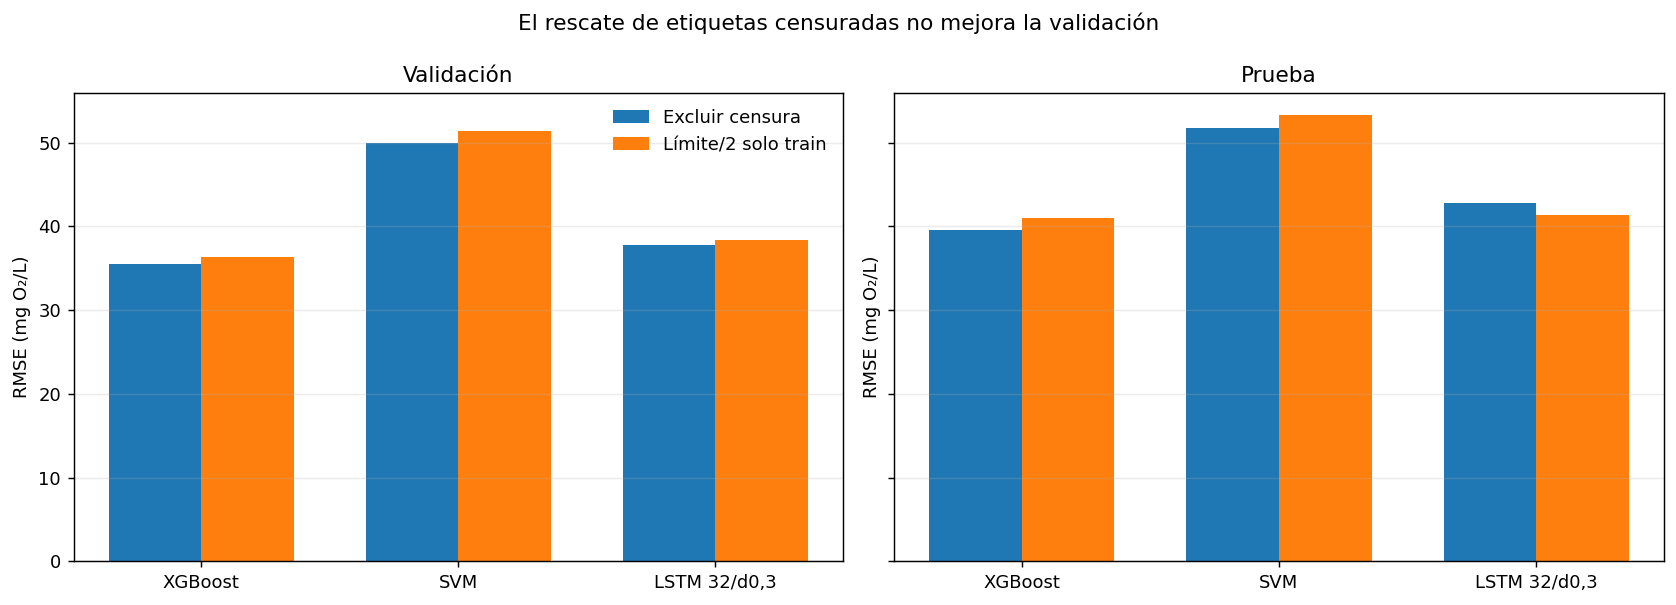

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.7), sharey=True)
etiquetas = ['XGBoost', 'SVM', 'LSTM 32/d0,3']
sin_rescate = ['XGBoost__exclude', 'SVM__exclude', 'LSTM_32_d03__exclude']
con_rescate = ['XGBoost__train_half_limit', 'SVM__train_half_limit', 'LSTM_32_d03__train_half_limit']
for ax, tabla, titulo in [(axes[0], validacion_censura, 'Validación'), (axes[1], prueba_censura, 'Prueba')]:
    base = [tabla.loc[tabla.candidate.eq(nombre), 'RMSE'].iloc[0] for nombre in sin_rescate]
    rescate = [tabla.loc[tabla.candidate.eq(nombre), 'RMSE'].iloc[0] for nombre in con_rescate]
    x = np.arange(len(etiquetas))
    ax.bar(x - 0.18, base, width=0.36, label='Excluir censura')
    ax.bar(x + 0.18, rescate, width=0.36, label='Límite/2 solo train')
    ax.set(xticks=x, xticklabels=etiquetas, title=titulo, ylabel='RMSE (mg O₂/L)')
    ax.grid(axis='y', alpha=0.25)
axes[0].legend(frameon=False)
fig.suptitle('El rescate de etiquetas censuradas no mejora la validación')
fig.tight_layout()
plt.show()


## 10. Decisiones y siguientes experimentos

- El reemplazo por la mitad del límite recuperó 718 ejemplos de entrenamiento, pero empeoró el RMSE de validación de XGBoost, SVM y LSTM. Por ello **se intentó y no aportó al aprendizaje del modelo**. La mejora aislada de LSTM en prueba no se usa para seleccionar, porque su validación empeoró.
- La LSTM de 32 unidades, dropout 0,3 y parada temprana sobre RMSE físico fue la mejor variante LSTM en validación sin rescate. Reduce el error frente a la LSTM original, aunque XGBoost sigue siendo el mejor modelo global.
- Los pesos regionales 2, 3 y 5 para la subzona `2,120`, el perfil regional como predictor y cuatro regularizaciones adicionales de XGBoost empeoraron la validación. El modelo conservado obtuvo RMSE 35,451 global y 77,830 en la subzona; con peso 5 aumentaron a 37,844 y 88,471. No se incorporaron al pipeline.
- El R² regional solo se presenta cuando hay al menos 20 observaciones y dos estaciones. El resumen ponderado informa cuántas observaciones entraron y cuántas quedaron fuera; sirve para localizar variación territorial del error, no para reemplazar el R² global.
- El siguiente intento debe confirmarse con varios cortes temporales. Las opciones prioritarias son una pérdida censurada o por intervalos, calendarios climáticos regionales, validación dejando estaciones completas fuera y una ablación de covariables e historia de DQO.
